# Visulaization Problem Sheet 1 - Solutions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Exercise 1.1

In [2]:
# import data set, inspect dtypes and the dataframe
mpg_df = pd.read_csv('mpg-data.csv')
print(mpg_df.dtypes)
mpg_df

manufacturer     object
model            object
displ           float64
year              int64
cyl               int64
trans            object
drv              object
cty               int64
hwy               int64
fl               object
class            object
dtype: object


,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
0,audi,a4,1.8,1999,4,auto(l5),f,18,29,p,compact
1,audi,a4,1.8,1999,4,manual(m5),f,21,29,p,compact
2,audi,a4,2.0,2008,4,manual(m6),f,20,31,p,compact
3,audi,a4,2.0,2008,4,auto(av),f,21,30,p,compact
4,audi,a4,2.8,1999,6,auto(l5),f,16,26,p,compact
...,...,...,...,...,...,...,...,...,...,...,...
229,volkswagen,passat,2.0,2008,4,auto(s6),f,19,28,p,midsize
230,volkswagen,passat,2.0,2008,4,manual(m6),f,21,29,p,midsize
231,volkswagen,passat,2.8,1999,6,auto(l5),f,16,26,p,midsize
232,volkswagen,passat,2.8,1999,6,manual(m5),f,18,26,p,midsize


In [3]:
# to specify dtypes the follow can be used:
dtypes = {'manufacturer':str,'model':str,'displ':float,'year':int,'cyl':int,'trans':str,'drv':str,'cty':int,'hwy':int,'fl':str,'class':str}
mpg_df = pd.read_csv('mpg-data.csv',dtype=dtypes)
mpg_df.dtypes

manufacturer     object
model            object
displ           float64
year              int64
cyl               int64
trans            object
drv              object
cty               int64
hwy               int64
fl               object
class            object
dtype: object

Text(0, 0.5, 'Highway fuel efficiency in mpg')

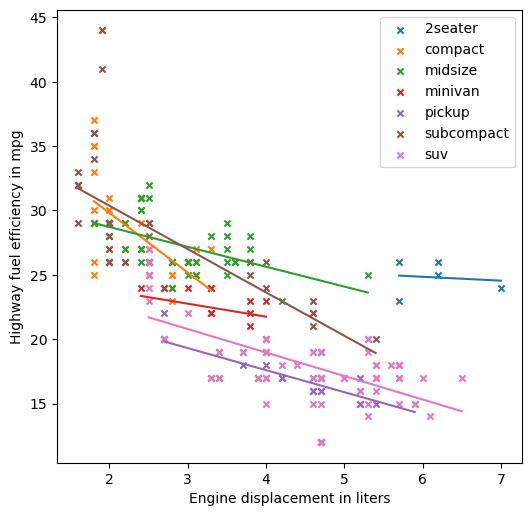

In [4]:
# perform linear regression on hwy and displ
from sklearn.linear_model import LinearRegression

fig, ax = plt.subplots(1,1,figsize=(6,6),dpi=100)

for cls in np.unique(mpg_df['class']):
    #print(cls)
    
    # get indices of rows in the given class
    idx = mpg_df['class'] == cls
    #print(mpg_df[idx])
    
    # extract hwy and displ values
    displ = mpg_df[idx]['displ'].to_numpy()[:,None] # needs to be 2-d array
    hwy = mpg_df[idx]['hwy'].to_numpy()
    #print(displ.shape,hwy.shape)
    
    # do linear regression
    model = LinearRegression()
    model.fit(displ,hwy)
    
    # scatter plot
    ax.scatter(displ, hwy, label = cls, s = 20, marker = 'x')

    # plot linear regression on the range of displ with the same (automatic) colors
    x_range = [[displ.min()],[displ.max()]]
    #x_range = [[mpg_df['displ'].min()],[mpg_df['displ'].max()]] # another option for x_range
    y_range = model.predict(x_range)
    ax.plot(x_range, y_range)

# plot Labels and legend
ax.legend()
ax.set_xlabel("Engine displacement in liters")
ax.set_ylabel("Highway fuel efficiency in mpg")

In [5]:
# get median of hwy grouped by class and year
median_hwy_by_class_year = mpg_df.groupby(by=['class','year'])['hwy'].median().reset_index()
print(type(median_hwy_by_class_year))
print(median_hwy_by_class_year)

<class 'pandas.core.frame.DataFrame'>
         class  year   hwy
0      2seater  1999  24.5
1      2seater  2008  25.0
2      compact  1999  26.0
3      compact  2008  29.0
4      midsize  1999  26.0
5      midsize  2008  28.0
6      minivan  1999  22.0
7      minivan  2008  23.0
8       pickup  1999  17.0
9       pickup  2008  17.0
10  subcompact  1999  26.0
11  subcompact  2008  26.5
12         suv  1999  17.0
13         suv  2008  18.0


## Exercise 1.2

In [6]:
# Task 1: inspect, import and tidy dataset
## Import the dataset ignoring comments
runtimes_df = pd.read_csv('runtimes.csv', comment='#')
#print(runtimes_df)

## melt values of timeX into a single column
runtimes_df = pd.melt(runtimes_df,id_vars=['algo','size'],var_name='number of threads',value_name='runtime')
#print(runtimes_df)

## remove rows where the value is NAN
runtimes_df = runtimes_df.dropna()
#print(runtimes_df)

## transform string in 'threads' column 'timeX' -> X as int
runtimes_df['number of threads'] = runtimes_df['number of threads'].apply(lambda x : int(x[-1]))
#print(runtimes_df)

## rename columns
runtimes_df = runtimes_df.rename(columns = {"algo": "algorithm type",
"size": "problem size"})
#runtimes_df = runtimes_df.rename(columns = {"number of threads":"threads"})
print(runtimes_df)

   algorithm type  problem size  number of threads      runtime
0     distributed          4096                  1     3.736606
1     distributed         16384                  1    14.792794
2     distributed         65536                  1    59.123347
3     distributed        262144                  1   240.747448
4     distributed       1048576                  1  1097.788352
5     distributed       4194304                  1  4845.007061
6          single          4096                  1     3.622693
7          single         16384                  1    26.792361
8          single         65536                  1   127.812326
9          single        262144                  1   281.994783
10    distributed          4096                  2     2.133074
11    distributed         16384                  2     7.894031
12    distributed         65536                  2    30.762486
13    distributed        262144                  2   124.448679
14    distributed       1048576         

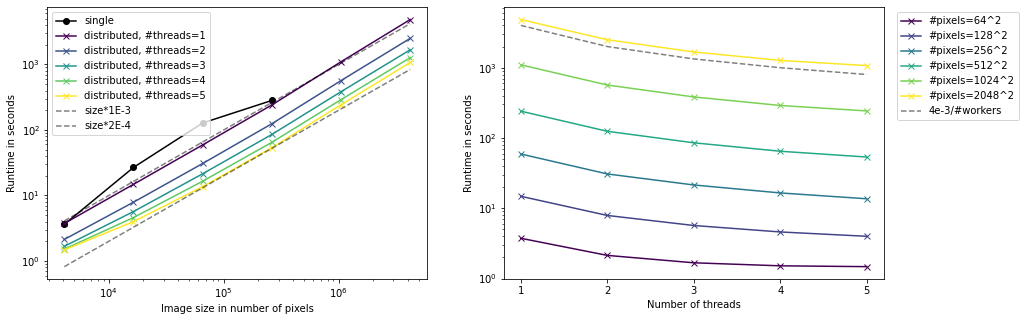

In [7]:
import matplotlib.cm as cm # for using a colour map

# create figure and axes for two plots
fig, ax = plt.subplots(1,2,figsize=(15,5))

# Task 2: run time vs. image size
## plot runtimes for algorithms with single core
idx = runtimes_df['algorithm type'] == 'single'
rt_df = runtimes_df[idx]
ps = rt_df['problem size'].to_numpy()
rt = rt_df['runtime'].to_numpy()

## use log scale on both axes
ax[0].loglog(ps,rt,label='single',c='k',marker='o')

## plot runtimes for distributed algorithms
thread_list = np.unique(runtimes_df['number of threads'])

for i, num_threads in enumerate(thread_list):

    idx = (runtimes_df['algorithm type'] == 'distributed')&(runtimes_df['number of threads'] == num_threads)
    rt_df = runtimes_df[idx]
    ps = rt_df['problem size'].to_numpy()
    rt = rt_df['runtime'].to_numpy()
    
    ## use log scale on both axes, and colour according to number of threads
    ax[0].loglog(ps,rt,label='distributed, #threads='+str(num_threads),marker='x',c=cm.viridis(i/(len(thread_list)-1)))
    
ax[0].set_xlabel("Image size in number of pixels")
ax[0].set_ylabel("Runtime in seconds")

## reference lines
prob_sizes = np.unique(runtimes_df['problem size'])
ax[0].loglog(prob_sizes,prob_sizes*1e-3,ls="dashed",label="size*1E-3",c='k',alpha=0.5)
ax[0].loglog(prob_sizes,prob_sizes*2e-4,ls="dashed",label="size*2E-4",c='k',alpha=0.5)

ax[0].legend()

# Task 3: Runtimes against number of threads
## plot runtimes for distributed algorithms
imsz_list = np.unique(runtimes_df['problem size'])

for i, imsz in enumerate(imsz_list):

    idx = (runtimes_df['algorithm type'] == 'distributed')&(runtimes_df['problem size'] == imsz)
    rt_df = runtimes_df[idx]
    nt = rt_df['number of threads'].to_numpy()
    rt = rt_df['runtime'].to_numpy()
    
    ## use log scale on both axes, and colour according to number of threads
    label="#pixels={:}^2".format(int(imsz**0.5))
    ax[1].semilogy(nt,rt,label=label,marker='x',c=cm.viridis(i/(len(imsz_list)-1)))
    
ax[1].set_xlabel("Number of threads")
ax[1].set_ylabel("Runtime in seconds")

## reference lines
num_threads = np.unique(runtimes_df['number of threads'])
ax[1].semilogy(num_threads,4e+3/num_threads,ls="dashed",label="4e-3/#workers",c='k',alpha=0.5)
ax[1].set_xticks(num_threads)
ax[1].legend(bbox_to_anchor=(1.02,1.0))

## Exercise 1.3

In [8]:
import cv2

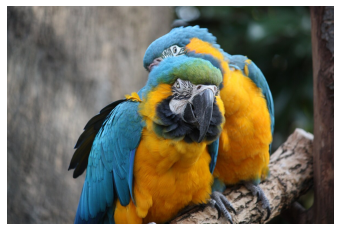

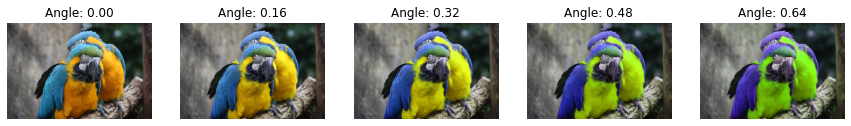

In [9]:
# Load the image (automatically loads as BGR)
image_bgr = cv2.imread('BlueAndYellowMacaw_AraArarauna.jpg')

# Convert the image from BGR to RGB and plot to check colour
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.axis('off')
plt.show()

# Convert the image to HSV space
image_hsv = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2HSV)

def rotate_hue(image, angle):
    # Extract the hue channel
    hue = image[:, :, 0]
    
    # Apply the hue rotation, accounting for the fact that hue ranges from 0 to 255 here
    rotated_hue = (hue + 255*angle/(2*np.pi)) % 255
    
    # Replace the hue channel with the rotated hue
    image_rotated = np.copy(image)
    image_rotated[:, :, 0] = rotated_hue
    
    return image_rotated

# List of angles for rotation
angles = [k/(2*np.pi) for k in range(5)]

# Apply rotation and visualize the images
plt.figure(figsize=(15, 5))
for i, angle in enumerate(angles):
    # Rotate the hue channel
    rotated_image_hsv = rotate_hue(image_hsv, angle)
    
    # Convert back to RGB space
    rotated_image_rgb = cv2.cvtColor(rotated_image_hsv, cv2.COLOR_HSV2RGB)
    
    # Plot the image
    plt.subplot(1, 5, i + 1) # this is another way to make subplots
    plt.imshow(rotated_image_rgb)
    plt.title(f'Angle: {angle:.2f}')
    plt.axis('off')

plt.show()